In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float64, complex128
from numba.cuda import jit as cuda_jit
import math

import few

from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode import KerrEccEqFlux
from few.amplitude.ampinterp2d import AmpInterpKerrEccEq
from few.summation.interpolatedmodesum import InterpolatedModeSum 


from few.utils.ylm import GetYlms

from few import get_file_manager

from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform

from few.utils.geodesic import get_fundamental_frequencies

from few.utils.constants import YRSID_SI

import os
import sys

# Change to the desired directory
os.chdir('/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

# Add it to Python path
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work/')

import GWfuncs
import loglike
import modeselector
import dynesty
# import gc
# import pickle
import cupy as cp

# tune few configuration
cfg_set = few.get_config_setter(reset=True)
cfg_set.set_log_level("info")



In [2]:
# GPU configuration 
use_gpu = True
force_backend = "cuda12x"  
dt = 10     # Time step
T = 1    # Total time


In [3]:

# keyword arguments for inspiral generator 
inspiral_kwargs={
        "func": 'KerrEccEqFlux',
        "DENSE_STEPPING": 0, #change to 1/True for uniform sampling
        "include_minus_m": False, 
}

# keyword arguments for inspiral generator 
amplitude_kwargs = {
    "force_backend": force_backend,
    # "use_gpu" : use_gpu
}

# keyword arguments for Ylm generator (GetYlms)
Ylm_kwargs = {
    "force_backend": force_backend,
    # "assume_positive_m": True  # if we assume positive m, it will generate negative m for all m>0
}

# keyword arguments for summation generator (InterpolatedModeSum)
sum_kwargs_comb = {
    "force_backend":force_backend,
    "pad_output": True,
    "separate_modes": False
    # "use_gpu" : use_gpu
}

sum_kwargs_sep = {
    "force_backend":force_backend,
    "pad_output": True,
    "separate_modes": True
    # "use_gpu" : use_gpu
}

print("Creating FastKerrEccentricEquatorialFlux...")
# Kerr eccentric flux
waveform_gen_sep = FastKerrEccentricEquatorialFlux(
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_sep,
    use_gpu=use_gpu,
)

# Kerr eccentric flux
waveform_gen_comb = FastKerrEccentricEquatorialFlux(
    inspiral_kwargs=inspiral_kwargs,
    amplitude_kwargs=amplitude_kwargs,
    Ylm_kwargs=Ylm_kwargs,
    sum_kwargs=sum_kwargs_comb,
    use_gpu=use_gpu,
)

Creating FastKerrEccentricEquatorialFlux...


In [4]:
#Generating data (true)

m1 = 1e6
m2 = 1e1
a = 0.5
p0 = 10.0
e0 = 0.2
xI0 = 1.0 #NOTE: fixed, equatorial
dist = 1
theta = np.pi/3
phi = np.pi/2

In [5]:
gwf = GWfuncs.GravWaveAnalysis(T=T, dt=dt, use_gpu=True)

In [6]:
traj = EMRIInspiral(func=KerrEccEqFlux, include_minus_m=False) 
amp = AmpInterpKerrEccEq(force_backend="cuda12x") # default lmax=10, nmax=55
interpolate_mode_sum = InterpolatedModeSum(force_backend="cuda12x", pad_output=True, separate_modes=False)
ylm_gen = GetYlms(include_minus_m=False, force_backend="cuda12x")

In [7]:
(t, p, e, x, Phi_phi, Phi_theta, Phi_r) = traj(m1, m2, a, p0, e0, xI0, T=T, dt=dt)
teuk_modes = amp(a, p, e, x)
ylms = ylm_gen(amp.unique_l, amp.unique_m, theta, phi).copy()[amp.inverse_lm]


In [8]:
m0mask = amp.m_arr_no_mask != 0
total_power = gwf.calc_power(teuk_modes, ylms, m0mask)


In [9]:
# Get mode labels
mode_labels = [f"({l},{m},{n})" for l,m,n in zip(amp.l_arr, amp.m_arr, amp.n_arr)]

In [10]:
M_mode = 5
ma = list(zip(mode_labels, total_power.get())) 
# Sort by power and pick top 100 modes
ma_sorted = sorted(ma, key=lambda x: x[1], reverse=True)[:M_mode]
ma_modes = [x[0] for x in ma_sorted]
ma_power = [x[1] for x in ma_sorted]

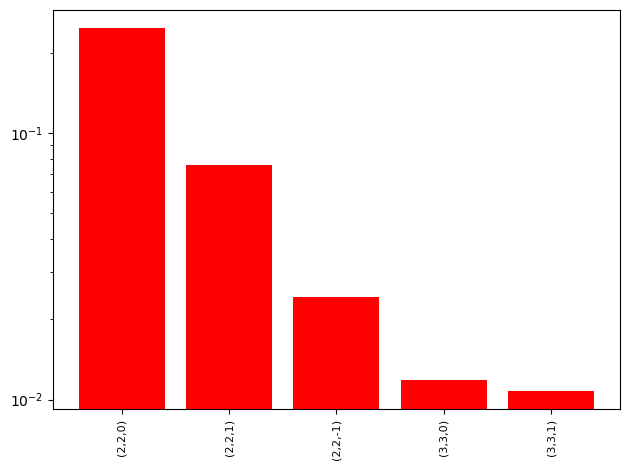

In [11]:

plt.bar(range(len(ma_power)), ma_power, color='red')
plt.xticks(range(len(ma_modes)), ma_modes, rotation=90, fontsize=8)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [12]:
modes =  [(2,2,0),(2,2,1),(2,2,-1)]


In [13]:
wave_full = waveform_gen_comb(
    m1, 
    m2,
    a, 
    p0, 
    e0, 
    xI0, 
    theta, 
    phi, 
    dist=dist, 
    dt=dt, 
    T=1, 
    # mode_selection=pos_mode,
    # include_minus_mkn=False,
)


In [14]:
wave_modes = waveform_gen_sep(
    m1, 
    m2,
    a, 
    p0, 
    e0, 
    xI0, 
    theta, 
    phi, 
    dist=dist, 
    dt=dt, 
    T=1, 
    mode_selection=modes,
    include_minus_mkn=False,
)


In [17]:
wave_full.shape

(3155815,)

In [18]:
wave_modes.shape

(3155815, 3)

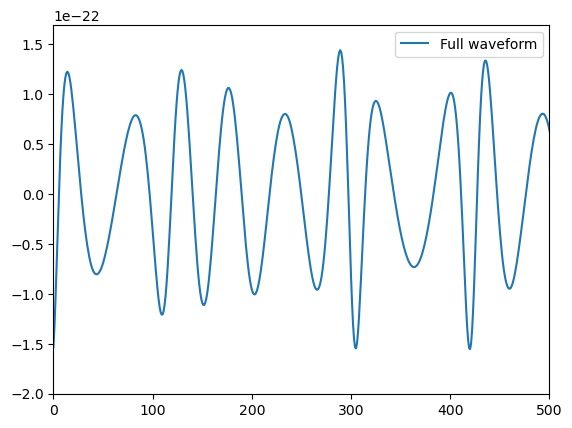

In [24]:
plt.plot(wave_full.get().real, label='Full waveform')

# plt.plot(wave_neg[:,0].get().real, label='(2,-2,0) h_plus')
# plt.plot(wave_neg[:,0].get().imag, label='(2,-2,0) h_cross')
# plt.plot(wave_neg[:,1].get().real, label='(2,-1,0) h_plus')
# plt.plot(wave_neg[:,1].get().imag, label='(2,-1,0) h_cross')
plt.xlim(0, 500)
plt.legend()
plt.show()


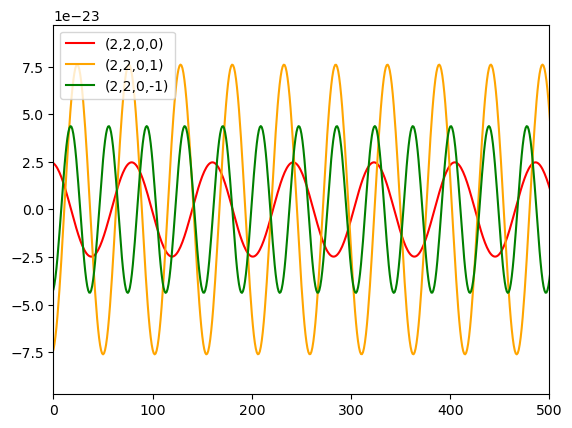

In [27]:
plt.plot(wave_modes[:,0].get().real, label='(2,2,0,0)', color='red')
plt.plot(wave_modes[:,1].get().real, label='(2,2,0,1)', color='orange')
plt.plot(wave_modes[:,2].get().real, label='(2,2,0,-1)', color='green')
plt.xlim(0, 500)
plt.legend()
plt.show()